## Lab 2: final challenges

In [1]:
import os
import copy
import random
import urllib.request
import zipfile

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim import SGD, Adam, AdamW

from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    StepLR
)

from torch.utils.data import (
    DataLoader,
    Subset
)

from torchvision import (
    datasets,
    transforms,
    models
)

from sklearn.model_selection import train_test_split

from tqdm import tqdm

%matplotlib inline

In [2]:
plt.rcParams.update({
    "font.size": 14
})

torch.backends.cudnn.benchmark = True

После выполнения задания заполните небольшой отчет об экспериментах вида "Я пробовал(а) ... подходы и получил(а) ... результаты. Наконец, после N+1 чашки кофе/бессонной ночи у меня получилось, и весь секрет был в ..."

### Part 5. Dogs classification (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.

Предлагаем вам решить задачу классификации пород собак. Вы можете обучить сеть с нуля или же воспользоваться методом fine-tuning'а. Полезная ссылка на [предобученные модели](https://pytorch.org/docs/stable/torchvision/models.html).

Данные можно скачать [отсюда](https://www.dropbox.com/s/vgqpz2f1lolxmlv/data.zip?dl=0). Датасет представлен 50 классами пород собак, которые можно найти в папке train в соответствующих директориях. При сдаче данной части задания вместе с ноутбуком необходимо отправить .csv-файл с предсказаниями классов тестовой выборки в формате: <имя изображения>,<метка класса> по одному объекту на строку. Ниже приведите код ваших экспериментов и короткий вывод по их результатам.

Будут оцениваться качество классификации (accuracy) на тестовой выборке (2 балла) и проведенные эксперименты (1 балл).
Разбалловка следующая:
* $>=$93% - 2 points
* $>=$84% - 1.5 points
* $>=$70% - 0.75 points

In [3]:
import os
import urllib.request
import zipfile
from pathlib import Path

target_dir = "/home/dima/Документы/ml/ML_algorithms/lab02_deep_learning"

#dl=1
url = "https://www.dropbox.com/scl/fi/v4mlweruozv8dbf4fx2xi/data.zip?rlkey=xke12fmqcui4malrwoqveqaai&e=1&dl=1"

#будет сохранён в target_dir
zip_name = "data.zip"
zip_path = os.path.join(target_dir, zip_name)

#целевая папка
Path(target_dir).mkdir(parents=True, exist_ok=True)

if not os.path.exists(zip_path):
    print("Скачивание датасета...")
    urllib.request.urlretrieve(url, zip_path)
    print("Скачивание завершено!")
else:
    print("Архив уже существует, пропускаем скачивание.")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_dir)
    print("Распаковка завершена!")

print(f"Данные готовы в {target_dir}")

Скачивание датасета...
Скачивание завершено!
Распаковка завершена!
Данные готовы в /home/dima/Документы/ml/ML_algorithms/lab02_deep_learning


In [4]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split

from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    StepLR
)

from tqdm import tqdm

import copy

data_dir = "/home/dima/Документы/ml/ML_algorithms/lab02_deep_learning/data/train"

train_full = datasets.ImageFolder(
    root=data_dir,
    transform=None
)

targets = train_full.targets

train_indices, val_indices = train_test_split(
    list(range(len(train_full))),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

print(f"Train images: {len(train_indices)}")
print(f"Validation images: {len(val_indices)}")

Train images: 5732
Validation images: 1434


In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)

IMAGENET_STD = (0.229, 0.224, 0.225)

common_train_transform = transforms.Compose([

    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(

        brightness=0.2,

        contrast=0.2,

        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        IMAGENET_MEAN,

        IMAGENET_STD
    )
])

common_val_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(

        IMAGENET_MEAN,

        IMAGENET_STD
    )
])

In [6]:
COMMON_BENCHMARK = {

    "batch_size": 32,

    "train_transform": common_train_transform,

    "val_transform": common_val_transform,
}

COMMON_PHASE1 = {

    "epochs": 8,

    "optimizer": {

        "class": Adam,

        "params": {

            "lr": 1e-4,

            "weight_decay": 1e-4
        }
    },

    "scheduler": None,

    "freeze_backbone": True
}

COMMON_PHASE2 = {

    "epochs": 12,

    "optimizer": {

        "class": Adam,

        "params": {

            "lr": 1e-5,

            "weight_decay": 1e-4
        }
    },

    "scheduler": None,

    "freeze_backbone": False
}

EXPERIMENT = {

    "mode": "benchmark",

    "device": "cuda",

    "save_model": True,

    "save_history": True,

    "results_dir": "results"
}

list_of_models = [

    "resnet50",

    "efficientnet_b0",

    "mobilenet_v3_large",

    "vit_b_16"
]

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

In [7]:
MODEL_CONFIGS = {

    "resnet50": {

        "builder": models.resnet50,

        "weights": models.ResNet50_Weights.IMAGENET1K_V2,

        "classifier_name": "fc",

        "replace_classifier":
            lambda model, n:
                setattr(
                    model,
                    "fc",
                    nn.Linear(
                        model.fc.in_features,
                        n
                    )
                ),

        "optimal": {

            "phase1": {

                "optimizer": {
                    "class": SGD,
                    "params": {
                        "lr": 1e-2,
                        "momentum": 0.9,
                        "weight_decay": 1e-4
                    }
                },

                "scheduler":
                    lambda optimizer:
                        CosineAnnealingLR(
                            optimizer,
                            T_max=8
                        )
            },

            "phase2": {

                "optimizer": {
                    "class": SGD,
                    "params": {
                        "lr": 1e-3,
                        "momentum": 0.9,
                        "weight_decay": 1e-4
                    }
                },

                "scheduler":
                    lambda optimizer:
                        CosineAnnealingLR(
                            optimizer,
                            T_max=12
                        )
            }
        },

        "optuna": {

            "optimizer_choices": [SGD, Adam],

            "lr_range": (1e-5, 1e-2),

            "batch_choices": [16, 32, 64],

            "weight_decay_range": (1e-6, 1e-3),
        }
    },

    ##################################################################

    "efficientnet_b0": {

        "builder": models.efficientnet_b0,

        "weights": models.EfficientNet_B0_Weights.IMAGENET1K_V1,

        "classifier_name": "classifier",

        "replace_classifier":
            lambda model, n:
                model.classifier.__setitem__(
                    1,
                    nn.Linear(
                        model.classifier[1].in_features,
                        n
                    )
                ),

        "optimal": {

            "phase1": {

                "optimizer": {
                    "class": AdamW,
                    "params": {
                        "lr": 1e-4,
                        "weight_decay": 1e-4
                    }
                },

                "scheduler":
                    lambda optimizer:
                        CosineAnnealingLR(
                            optimizer,
                            T_max=8
                        )
            },

            "phase2": {

                "optimizer": {
                    "class": AdamW,
                    "params": {
                        "lr": 5e-5,
                        "weight_decay": 1e-4
                    }
                },

                "scheduler":
                    lambda optimizer:
                        CosineAnnealingLR(
                            optimizer,
                            T_max=12
                        )
            }
        },

        "optuna": {

            "optimizer_choices": [Adam, AdamW],

            "lr_range": (1e-5, 5e-4),

            "batch_choices": [16, 32],

            "weight_decay_range": (1e-6, 1e-2),
        }
    },

    ##################################################################

    "mobilenet_v3_large": {

        "builder": models.mobilenet_v3_large,

        "weights": models.MobileNet_V3_Large_Weights.IMAGENET1K_V2,

        "classifier_name": "classifier",

        "replace_classifier":
            lambda model, n:
                model.classifier.__setitem__(
                    3,
                    nn.Linear(
                        model.classifier[3].in_features,
                        n
                    )
                ),

        "optimal": {

            "phase1": {

                "batch_size": 64,

                "optimizer": {
                    "class": Adam,
                    "params": {
                        "lr": 1e-3,
                        "weight_decay": 1e-4
                    }
                },

                "scheduler": None
            },

            "phase2": {

                "batch_size": 64,

                "optimizer": {
                    "class": Adam,
                    "params": {
                        "lr": 1e-4,
                        "weight_decay": 1e-4
                    }
                },

                "scheduler": None
            }
        },

        "optuna": {

            "optimizer_choices": [Adam, AdamW],

            "lr_range": (1e-5, 1e-3),

            "batch_choices": [32, 64],

            "weight_decay_range": (1e-6, 1e-2),
        }
    },

    ##################################################################

    "vit_b_16": {

        "builder": models.vit_b_16,

        "weights": models.ViT_B_16_Weights.IMAGENET1K_V1,

        "classifier_name": "heads",

        "replace_classifier":
            lambda model, n:
                setattr(
                    model.heads,
                    "head",
                    nn.Linear(
                        model.heads.head.in_features,
                        n
                    )
                ),

        "optimal": {

            "phase1": {

                "batch_size": 16,

                "optimizer": {
                    "class": AdamW,
                    "params": {
                        "lr": 3e-5,
                        "weight_decay": 5e-2
                    }
                },

                "scheduler":
                    lambda optimizer:
                        CosineAnnealingLR(
                            optimizer,
                            T_max=8
                        )
            },

            "phase2": {

                "batch_size": 16,

                "optimizer": {
                    "class": AdamW,
                    "params": {
                        "lr": 1e-5,
                        "weight_decay": 5e-2
                    }
                },

                "scheduler":
                    lambda optimizer:
                        CosineAnnealingLR(
                            optimizer,
                            T_max=12
                        )
            }
        },

        "optuna": {

            "optimizer_choices": [AdamW],

            "lr_range": (1e-6, 5e-5),

            "batch_choices": [8, 16, 32],

            "weight_decay_range": (1e-5, 1e-2),
        }
    }
}

In [8]:
data_root = "/home/dima/Документы/ml/ML_algorithms/lab02_deep_learning/data"

train_dir = os.path.join(data_root, "train")

test_dir = os.path.join(data_root, "test")

def get_model(model_name, num_classes):

    cfg = MODEL_CONFIGS[model_name]

    model = cfg["builder"](
        weights=cfg["weights"]
    )

    cfg["replace_classifier"](
        model,
        num_classes
    )

    return model


def get_train_config(model_name, mode, phase):

    cfg = copy.deepcopy(COMMON_BENCHMARK)

    if phase == 1:
        cfg.update(COMMON_PHASE1)
    else:
        cfg.update(COMMON_PHASE2)

    if mode != "benchmark":

        phase_key = f"phase{phase}"

        cfg.update(
            MODEL_CONFIGS[model_name][mode][phase_key]
        )

    return cfg

def build_optimizer(model, cfg):

    optimizer_cfg = cfg["optimizer"]

    optimizer = optimizer_cfg["class"](

        model.parameters(),

        **optimizer_cfg["params"]
    )

    return optimizer


def build_scheduler(optimizer, cfg):

    if cfg["scheduler"] is None:
        return None

    return cfg["scheduler"](optimizer)

def build_dataloaders(cfg):

    train_dataset = Subset(

        datasets.ImageFolder(

            data_dir,

            transform=cfg["train_transform"]
        ),

        train_indices
    )

    val_dataset = Subset(

        datasets.ImageFolder(

            data_dir,

            transform=cfg["val_transform"]
        ),

        val_indices
    )

    train_loader = DataLoader(

        train_dataset,

        batch_size=cfg["batch_size"],

        shuffle=True,

        num_workers=4,

        pin_memory=True
    )

    val_loader = DataLoader(

        val_dataset,

        batch_size=cfg["batch_size"],

        shuffle=False,

        num_workers=4,

        pin_memory=True
    )

    return train_loader, val_loader

In [9]:
criterion = nn.CrossEntropyLoss()

def freeze_backbone(model, model_name):

    classifier_name = MODEL_CONFIGS[model_name]["classifier_name"]

    for param in model.parameters():
        param.requires_grad = False

    classifier = getattr(model, classifier_name)

    for param in classifier.parameters():
        param.requires_grad = True

def unfreeze_backbone(model):

    for param in model.parameters():
        param.requires_grad = True

def train_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [10]:
def train_phase(model, train_loader, val_loader,
                optimizer, scheduler, criterion,
                device, epochs, save_path=None):

    history = {

        "train_loss": [],

        "train_acc": [],

        "val_loss": [],

        "val_acc": []
    }

    best_val_acc = 0
    best_epoch = 0

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch(

            model,

            train_loader,

            optimizer,

            criterion,

            device
        )

        val_loss, val_acc = validate(

            model,

            val_loader,

            criterion,

            device
        )

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)

        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)

        history["val_acc"].append(val_acc)

        print(

            f"Epoch {epoch+1}/{epochs}"

            f" | Train Acc {train_acc:.2f}"

            f" | Val Acc {val_acc:.2f}"
        )

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_epoch = epoch + 1

            if save_path is not None:

                torch.save(
                    model.state_dict(),
                    save_path
                )

    return history, best_val_acc, best_epoch

In [11]:
def train_model(model_name):

    print("=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    num_classes = len(train_full.classes)

    model = get_model(model_name, num_classes)
    model.to(device)

    cfg = get_train_config(model_name, EXPERIMENT["mode"], phase=1) #phase1

    train_loader, val_loader = build_dataloaders(cfg)

    freeze_backbone(model, model_name)

    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer, cfg)

    phase1_history, _, _ = train_phase(

        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion,
        device,
        cfg["epochs"]
    )

    cfg = get_train_config(model_name, EXPERIMENT["mode"], phase=2) #phase2

    train_loader, val_loader = build_dataloaders(cfg)

    unfreeze_backbone(model)

    optimizer = build_optimizer(model,cfg)

    scheduler = build_scheduler(optimizer,cfg)

    model_path = os.path.join(EXPERIMENT["results_dir"], f"{model_name}_best.pth")

    phase2_history, best_acc, best_epoch = train_phase(

        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion,
        device,
        cfg["epochs"],
        save_path=model_path
    )

    history = {
        "phase1": phase1_history,
        "phase2": phase2_history,
        "best_val_acc": best_acc,
        "best_epoch": best_epoch
    }

    if EXPERIMENT["save_history"]:

        history_path = os.path.join(

            EXPERIMENT["results_dir"],

            f"{model_name}_history.pt"
        )

        torch.save(history, history_path)

    return history

In [12]:
os.makedirs(

    EXPERIMENT["results_dir"],

    exist_ok=True
)

In [13]:
def train_all_models():

    all_results = {}

    for model_name in list_of_models:

        print()

        print("=" * 100)

        print(model_name.upper())

        print("=" * 100)

        history = train_model(

            model_name
        )

        all_results[model_name] = history

    return all_results

In [14]:
all_results = train_all_models()


RESNET50
Training resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/180 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if nec

Epoch 1/8 | Train Acc 18.04 | Val Acc 55.02


100%|██████████| 45/45 [00:06<00:00,  6.89it/s]


Epoch 2/8 | Train Acc 51.12 | Val Acc 78.10


...

Epoch 10/12 | Train Acc 95.32 | Val Acc 97.77


100%|██████████| 45/45 [00:19<00:00,  2.36it/s]


Epoch 11/12 | Train Acc 95.29 | Val Acc 98.54


100%|██████████| 45/45 [00:18<00:00,  2.37it/s]

Epoch 12/12 | Train Acc 95.80 | Val Acc 98.47


In [15]:
def compare_models(results):

    rows = []

    for model_name, history in results.items():

        rows.append({

            "Model": model_name,

            "Best Validation Accuracy":

                history["best_val_acc"],

            "Last Train Accuracy":

                history["phase2"]["train_acc"][-1],

            "Last Validation Accuracy":

                history["phase2"]["val_acc"][-1]
        })

    df = pd.DataFrame(rows)

    df = df.sort_values(

        "Best Validation Accuracy",

        ascending=False
    )

    return df

In [16]:
results_df = compare_models(

    all_results
)

results_df

,Model,Best Validation Accuracy,Last Train Accuracy,Last Validation Accuracy
3,vit_b_16,98.675035,95.795534,98.465830
0,resnet50,96.234310,88.398465,96.094840
1,efficientnet_b0,91.771269,79.553385,91.631799
2,mobilenet_v3_large,90.794979,84.176553,90.655509


In [17]:
def plot_history(

    history,

    title
):

    plt.figure(

        figsize=(12,5)
    )

    plt.subplot(1,2,1)

    plt.plot(

        history["phase1"]["train_loss"]

        +

        history["phase2"]["train_loss"],

        label="Train"
    )

    plt.plot(

        history["phase1"]["val_loss"]

        +

        history["phase2"]["val_loss"],

        label="Validation"
    )

    plt.title(

        f"{title} Loss"
    )

    plt.legend()

    plt.subplot(1,2,2)

    plt.plot(

        history["phase1"]["train_acc"]

        +

        history["phase2"]["train_acc"],

        label="Train"
    )

    plt.plot(

        history["phase1"]["val_acc"]

        +

        history["phase2"]["val_acc"],

        label="Validation"
    )

    plt.title(

        f"{title} Accuracy"
    )

    plt.legend()

    plt.show()

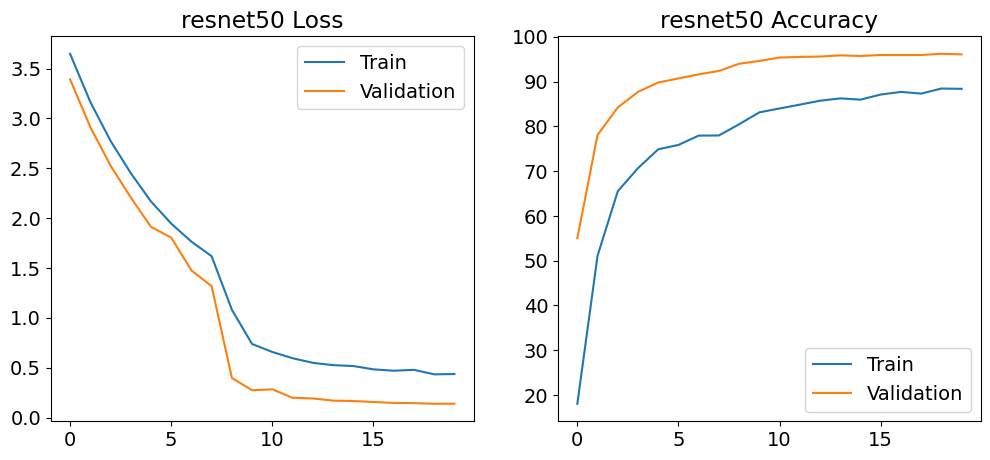

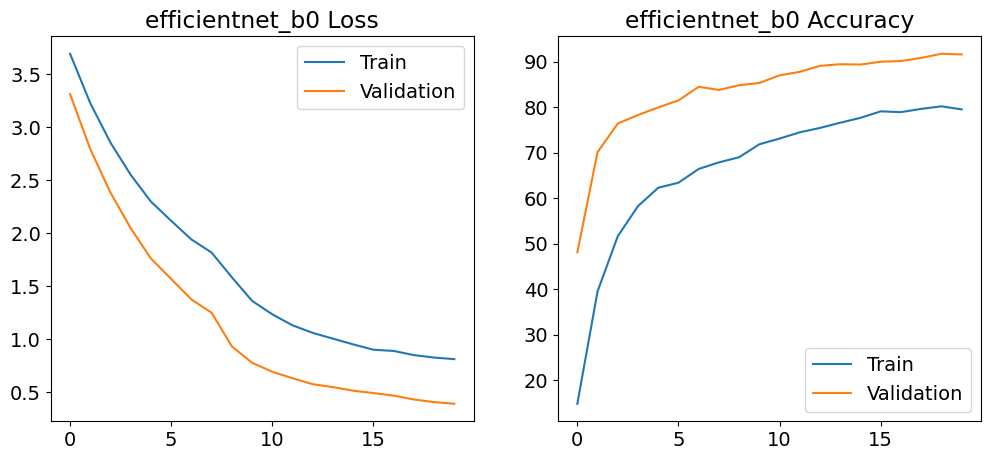

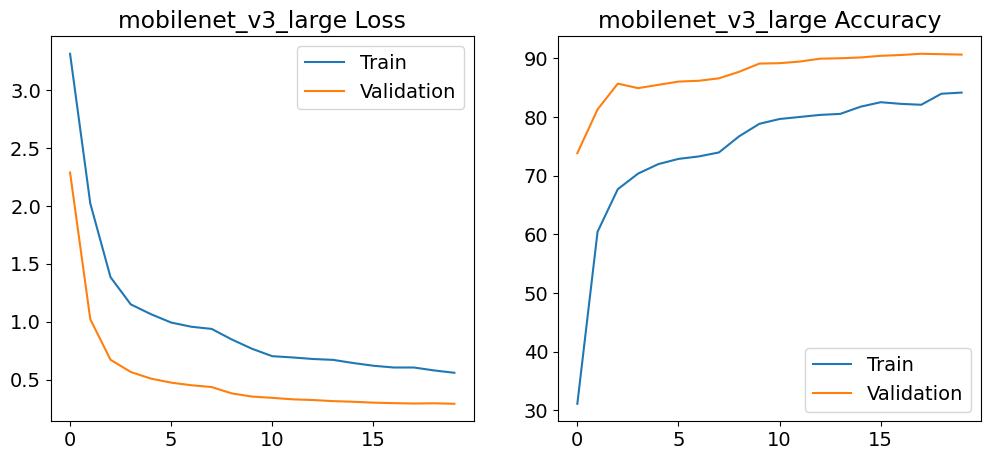

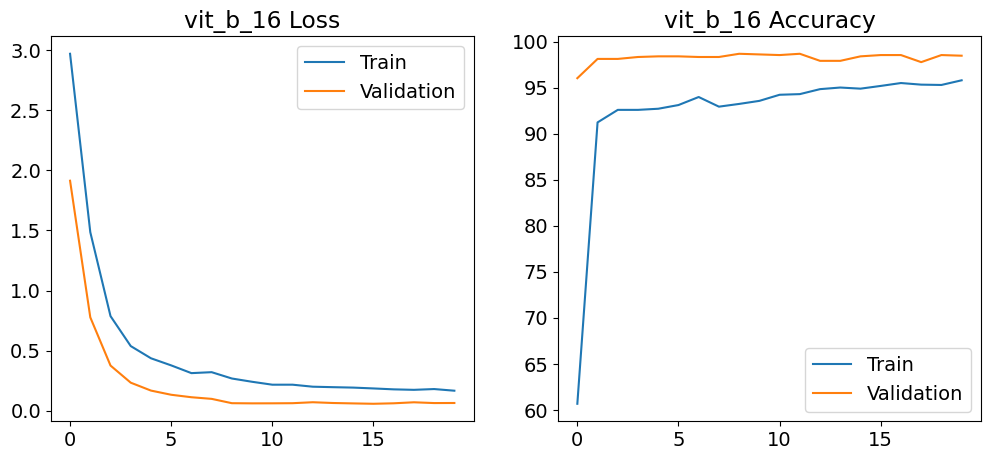

In [18]:
for model_name in list_of_models:

    plot_history(

        all_results[model_name],

        model_name
    )

In [19]:
best_model = max(

    all_results,

    key=lambda m:

        all_results[m]["best_val_acc"]
)

print(

    f"Best model: {best_model}"
)

print(

    f"Accuracy: {all_results[best_model]['best_val_acc']:.2f}%"
)

Best model: vit_b_16
Accuracy: 98.68%


In [20]:
class TestDataset(torch.utils.data.Dataset):

    def __init__(

        self,

        root,

        transform
    ):

        self.root = root

        self.transform = transform

        self.images = sorted(

            os.listdir(root)
        )

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(

            self.root,

            img_name
        )

        image = datasets.folder.default_loader(

            img_path
        )

        image = self.transform(image)

        return image, img_name

In [21]:
model = get_model(

    best_model,

    len(train_full.classes)
)

model.load_state_dict(

    torch.load(

        os.path.join(

            EXPERIMENT["results_dir"],

            f"{best_model}_best.pth"
        )
    )
)

model.to(device)

model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [22]:
test_dataset = TestDataset(

    test_dir,

    common_val_transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=4
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [23]:
predictions = []

with torch.no_grad():

    for images, names in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        for i, name in enumerate(names):

            predictions.append(

                (

                    name,

                    train_full.classes[

                        preds[i]
                    ]
                )
            )

  0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 47/47 [00:20<00:00,  2.31it/s]


In [24]:
submission = pd.DataFrame(

    predictions,

    columns=[

        "image_name",

        "label"
    ]
)

submission.to_csv(

    "submission.csv",

    index=False
)

submission.head()

,image_name,label
0,0.jpeg,42
1,1.jpeg,3
2,10.jpeg,39
3,100.jpeg,18
4,1000.jpeg,35


In [25]:
EXPERIMENT["mode"] = "optimal"

all_results = train_all_models()


RESNET50
Training resnet50


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/180 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100

Epoch 1/8 | Train Acc 63.22 | Val Acc 94.70


100%|██████████| 45/45 [00:07<00:00,  5.64it/s]


Epoch 2/8 | Train Acc 81.12 | Val Acc 95.61


...

Epoch 10/12 | Train Acc 95.64 | Val Acc 98.33


100%|██████████| 90/90 [00:20<00:00,  4.50it/s]


Epoch 11/12 | Train Acc 95.69 | Val Acc 98.05


100%|██████████| 90/90 [00:20<00:00,  4.50it/s]

Epoch 12/12 | Train Acc 95.50 | Val Acc 98.05


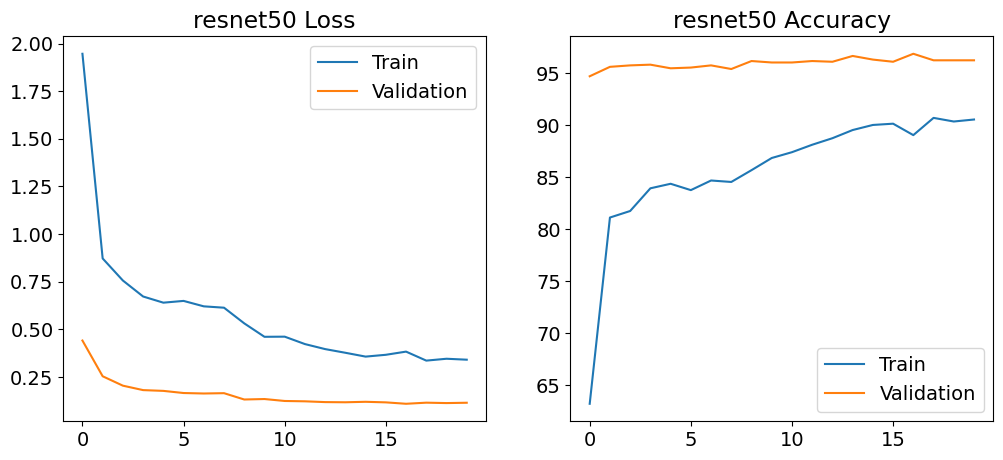

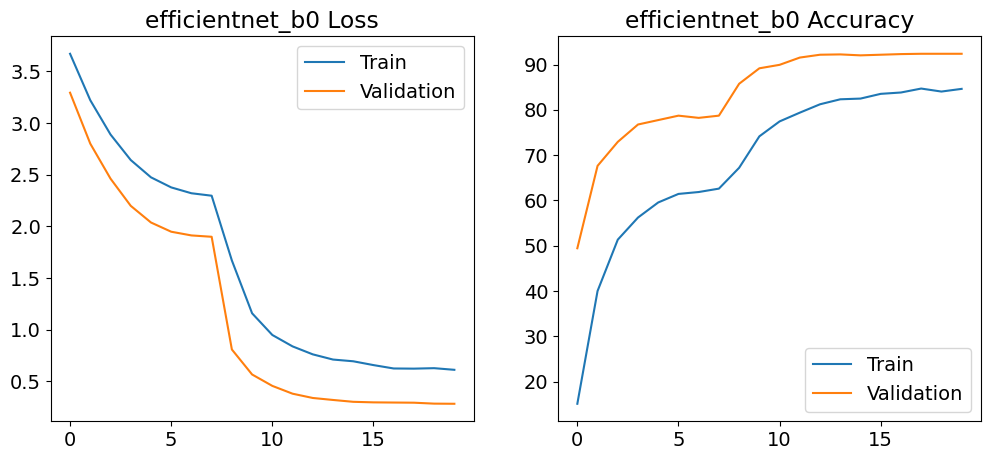

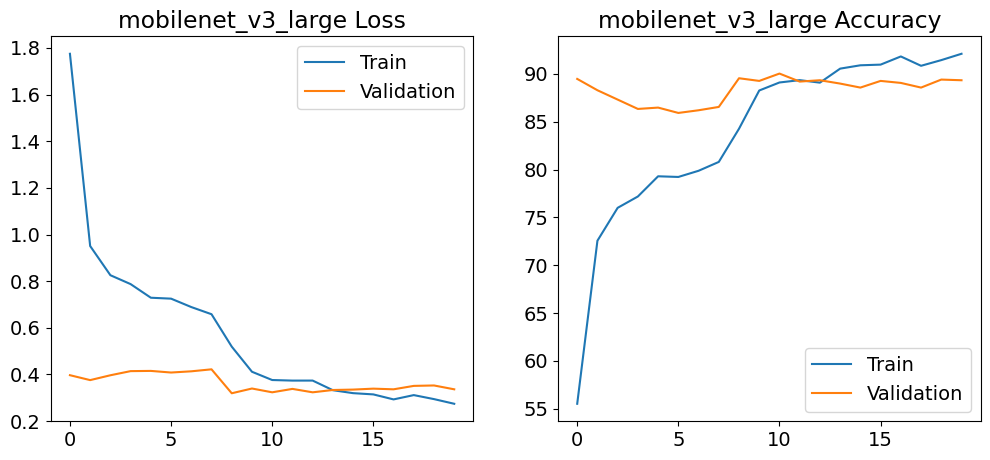

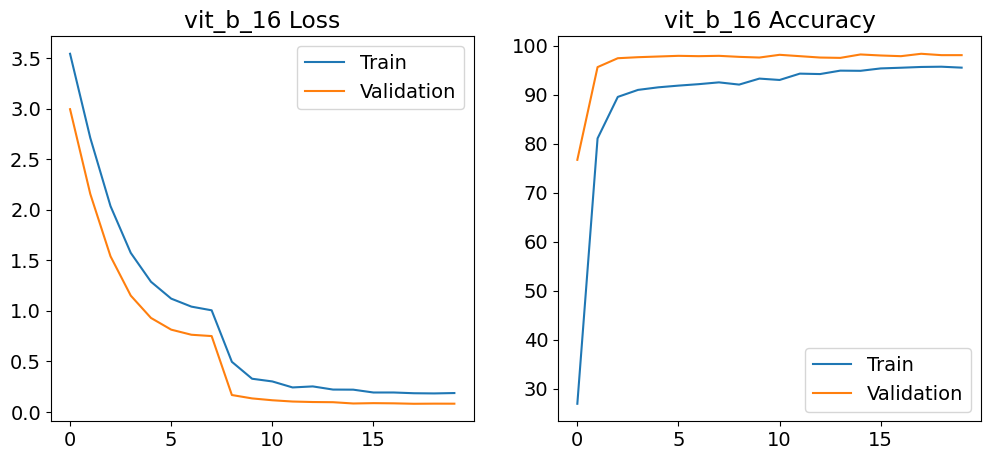

Best model: vit_b_16
Accuracy: 98.33%


100%|██████████| 47/47 [00:20<00:00,  2.35it/s]


,image_name,label
0,0.jpeg,42
1,1.jpeg,3
2,10.jpeg,39
3,100.jpeg,18
4,1000.jpeg,35


In [26]:
results_df = compare_models(all_results)

results_df

for model_name in list_of_models:

    plot_history(all_results[model_name], model_name)

best_model = max(

    all_results,
    key=lambda m:
        all_results[m]["best_val_acc"]
)

print(f"Best model: {best_model}")
print(f"Accuracy: {all_results[best_model]['best_val_acc']:.2f}%")

model = get_model(best_model, len(train_full.classes))

model.load_state_dict(

    torch.load(

        os.path.join(

            EXPERIMENT["results_dir"],

            f"{best_model}_best.pth"
        )
    )
)

model.to(device)

model.eval()

test_dataset = TestDataset(test_dir, common_val_transform)
test_loader = DataLoader(test_dataset, batch_size=32,
                         shuffle=False, num_workers=4)

predictions = []

with torch.no_grad():

    for images, names in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        for i, name in enumerate(names):

            predictions.append(

                (name, train_full.classes[preds[i]]))

submission = pd.DataFrame(

    predictions,

    columns=[

        "image_name",

        "label"
    ]
)

submission.to_csv(

    "submission.csv",

    index=False
)

submission.head()

In [27]:
results_df = compare_models(

    all_results
)

results_df

,Model,Best Validation Accuracy,Last Train Accuracy,Last Validation Accuracy
3,vit_b_16,98.326360,95.498953,98.047420
0,resnet50,96.861925,90.544313,96.234310
1,efficientnet_b0,92.398884,84.647592,92.398884
2,mobilenet_v3_large,90.027894,92.096999,89.330544


In [34]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/Best_models"
os.makedirs(SAVE_DIR, exist_ok=True)

for model_name, result in all_results.items():

    best_acc = result["best_val_acc"]

    # ---------- модель ----------
    model_src = os.path.join(
        "results",
        f"{model_name}_best.pth"
    )

    model_dst = os.path.join(
        SAVE_DIR,
        f"{model_name}_{best_acc:.2f}.pth"
    )

    shutil.copy(model_src, model_dst)

    # ---------- история ----------
    history_src = os.path.join(
        "results",
        f"{model_name}_history.pt"
    )

    history_dst = os.path.join(
        SAVE_DIR,
        f"{model_name}_{best_acc:.2f}_history.pt"
    )

    shutil.copy(history_src, history_dst)

    print(f"✓ {model_name} ({best_acc:.2f}%) сохранена")

print("\nВсе модели и истории обучения успешно сохранены!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ resnet50 (96.86%) сохранена
✓ efficientnet_b0 (92.40%) сохранена
✓ mobilenet_v3_large (90.03%) сохранена
✓ vit_b_16 (98.33%) сохранена

Все модели и истории обучения успешно сохранены!
